In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cmath
import math
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

In [2]:
h = 60
l = 1
factor = l/h**2
x = np.arange(-80, 100+h, h)
t = np.arange(0, 10+l, l)
len(x)

4

In [3]:
def u_exact(x,t):
    real_part = cmath.sqrt(0.02) * 1 / cmath.cosh(cmath.sqrt(0.01) * (x - 0.1*t))
    imag_part = cmath.cos(0.05*x - 3/400 * t) + 1j* cmath.sin(0.05*x - 3/400 * t)
    return real_part * imag_part

u_exact_values = np.zeros((len(x),len(t)), dtype=complex)

for i in range(len(x)):
  for j in range(len(t)):
    u_exact_values[i,j] = u_exact(i*h-80,j*l)

In [4]:
n = len(x)
m = len(t)
T = np.zeros((n,m), dtype = complex)
T[:, 0] = u_exact_values[:,0]
T[:, 1] = u_exact_values[:,1]
T_new = T.copy()
T.shape

(4, 11)

In [5]:
T

array([[-6.20197650e-05+7.18078039e-05j, -6.08677365e-05+7.15518206e-05j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j],
       [ 2.03100240e-02-3.16309883e-02j,  1.98795808e-02-3.14773928e-02j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j],
       [-2.15510284e-03+4.70898561e-03j, -2.14101425e-03+4.77247116e-03j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00

In [6]:
# Load the text file
T_values = np.loadtxt('C:/Users/ayazz/OneDrive/Desktop/Thesis/data/T_values.txt', delimiter=',')
T_values.shape
T_demo = np.loadtxt('C:/Users/ayazz/OneDrive/Desktop/Thesis/data/T_demo.txt', delimiter=',')
print(T_demo.shape)
#T_demo


(4, 22)


In [7]:
for i in range(T_demo.shape[1]):
    if i % 2 == 0:
        T[:, i//2] = T_demo[:, i] + 1j * T_demo[:, i+1]


In [8]:
T

array([[-6.20197650e-05+7.18078039e-05j, -6.08677365e-05+7.15518206e-05j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j],
       [ 2.03100240e-02-3.16309883e-02j,  1.98795808e-02-3.14773928e-02j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j],
       [-2.15510284e-03+4.70898561e-03j, -2.14101425e-03+4.77247116e-03j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00

In [9]:
# Find the first empty column in T
first_empty_col = np.where(T[0, :] == 0)[0][0]

# Insert T_values into the first empty column of T
T[:, first_empty_col] = T_values[:, 0] + 1j * T_values[:, 1]

print(T)

[[-6.20197650e-05+7.18078039e-05j -6.08677365e-05+7.15518206e-05j
  -3.75953370e-05+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j]
 [ 2.03100240e-02-3.16309883e-02j  1.98795808e-02-3.14773928e-02j
   1.98909179e-02-3.14652757e-02j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j]
 [-2.15510284e-03+4.70898561e-03j -2.14101425e-03+4.77247116e-03j
  -2.17436297e-03+4.79233646e-03j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.0

In [10]:
np.savetxt('C:/Users/ayazz/OneDrive/Desktop/Thesis/data/T_demo.txt', T.view(float), delimiter=',')

In [11]:
#a is the diagonal entries for real part, b is the diagonal entries for imaginary part, c and d are subdiagonal entries of a real part
def matrix_w(N, a, b, c, d):
    matrix_w = np.zeros((2*N, 2*N), dtype = float)
    np.fill_diagonal(matrix_w[:int(N),],a)
    np.fill_diagonal(matrix_w[:,int(N):],b)
    np.fill_diagonal(matrix_w[1:int(N),:],c)
    np.fill_diagonal(matrix_w[:-1,1:int(N)],d)
    matrix_w[0,1] = 2*matrix_w[0,1]
    matrix_w[int(N)-1,int(N)-2] = 2*matrix_w[int(N)-1,int(N)-2]
    return matrix_w

In [12]:
#B is the first half of a complex matrix converted to full real valued matrix
factor_real = -2 * factor
B = matrix_w(n, factor_real, -2, factor, factor)
#B[0,0:2]

In [13]:
#a is the diagonal entries for imaginary part, b is the diagonal entries for real part, c and d are subdiagonal entries of a imaginary part
def matrix_v(N, a, b, c, d):
    matrix_v = np.zeros((2*N, 2*N), dtype = float)
    np.fill_diagonal(matrix_v[int(N):,int(N):],a)
    np.fill_diagonal(matrix_v[int(N):,:],b)
    np.fill_diagonal(matrix_v[int(N)+1:,int(N):],c)
    np.fill_diagonal(matrix_v[int(N):,int(N)+1:],d)
    matrix_v[int(N),int(N)+1] = 2 * matrix_v[int(N),int(N)+1]
    matrix_v[2*N-1,2*N-2] = 2 * matrix_v[2*N-1,2*N-2]
    return matrix_v

In [14]:
C = matrix_v(n, factor_real, 2, factor, factor)
#C
D = B + C
#D = np.round(E, 7)
print(D.shape)
np.savetxt('C:/Users/ayazz/OneDrive/Desktop/Thesis/data/matrix.txt', D, delimiter=',')
D

(8, 8)


array([[-5.55555556e-04,  5.55555556e-04,  0.00000000e+00,
         0.00000000e+00, -2.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [ 2.77777778e-04, -5.55555556e-04,  2.77777778e-04,
         0.00000000e+00,  0.00000000e+00, -2.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  2.77777778e-04, -5.55555556e-04,
         2.77777778e-04,  0.00000000e+00,  0.00000000e+00,
        -2.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  5.55555556e-04,
        -5.55555556e-04,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -2.00000000e+00],
       [ 2.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -5.55555556e-04,  5.55555556e-04,
         0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  2.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  2.77777778e-04, -5.55555556e-04,
         2.77777778e-04,  0.00000000e+00],
       [ 0.00000000e+00,  0.000000

In [15]:
sol_real = np.zeros((len(x), len(t)), dtype = float)
sol_img = np.zeros((len(x), len(t)), dtype = float)
sol_real[:len(x),:len(t)] = T.real
sol_img[:len(x),:len(t)] = T.imag
#print(sol_real.shape)
#print(sol_img.shape)

In [16]:
solution_matrix = np.zeros((2*len(x), len(t)), dtype = float)
solution_matrix[:len(x),:] = sol_real
solution_matrix[len(x):,:] = sol_img
solution_matrix

array([[-6.20197650e-05, -6.08677365e-05, -3.75953370e-05,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [ 2.03100240e-02,  1.98795808e-02,  1.98909179e-02,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [-2.15510284e-03, -2.14101425e-03, -2.17436297e-03,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [ 3.64251726e-06,  3.58574253e-06,  3.75953370e-05,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [ 7.18078039e-05,  7.15518206e-05,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
  

In [17]:
w = solution_matrix[:len(x),:].copy()
v = solution_matrix[len(x):,:].copy()
#w

In [18]:
lam = 1
b = np.zeros((2*len(x), len(t)), dtype = float)
qwer = np.zeros((2*len(x), len(t)), dtype = float)

# Numerical approximation

In [89]:
lam = 1
b = np.zeros((2*len(x), len(t)), dtype = float)
qwer = np.zeros((2*len(x), len(t)), dtype = float)
w = solution_matrix[:len(x),:].copy()
v = solution_matrix[len(x):,:].copy()
i = 10
for z in range(0,n):
    if z == 0:
        w[z, i] = -factor * 2 * w[z+1,i-1] - 2 * v[z, i-1] + 2 * factor * w[z,i-1] - l * ((2 + 3 * lam) * ((w[z,i-1])**2 + (v[z,i-1])**2) - 2 * lam * np.sqrt((w[z, i-1])**2 + (v[z, i-1])**2) * np.sqrt((w[z, i-2])**2 + (v[z, i-2])**2)) * w[z, i-1] + lam * l * ((w[z, i-1])**2 + (v[z, i-1])**2) * w[z, i-2]
        v[z, i] = -factor * 2 * v[z+1,i-1] + 2 * w[z, i-1] + 2 * factor * v[z,i-1] - l * ((2 + 3 * lam) * ((w[z,i-1])**2 + (v[z,i-1])**2) - 2 * lam * np.sqrt((w[z, i-1])**2 + (v[z, i-1])**2) * np.sqrt((w[z, i-2])**2 + (v[z, i-2])**2)) * v[z, i-1] + lam * l * ((w[z, i-1])**2 + (v[z, i-1])**2) * v[z, i-2]

    elif z == n - 1:
        w[z, i] = -factor * 2 * w[-2,i-1] - 2 * v[-1, i-1] + 2 * factor * w[-1,i-1] - l * ((2 + 3 * lam) * ((w[-1,i-1])**2 + (v[-1,i-1])**2) - 2 * lam * np.sqrt((w[-1, i-1])**2 + (v[-1, i-1])**2) * np.sqrt((w[-1, i-2])**2 + (v[-1, i-2])**2)) * w[-1, i-1] + lam * l * ((w[-1, i-1])**2 + (v[-1, i-1])**2) * w[-1, i-2]
        v[z, i] = -factor * 2 * v[-2,i-1] + 2 * w[-1, i-1] + 2 * factor * v[-1,i-1] - l * ((2 + 3 * lam) * ((w[-1,i-1])**2 + (v[-1,i-1])**2) - 2 * lam * np.sqrt((w[-1, i-1])**2 + (v[-1, i-1])**2) * np.sqrt((w[-1, i-2])**2 + (v[-1, i-2])**2)) * v[-1, i-1] + lam * l * ((w[-1, i-1])**2 + (v[-1, i-1])**2) * v[-1, i-2]

    else:
        w[z, i] = -factor * w[z-1,i-1] - factor * w[z+1,i-1] - 2 * v[z, i-1] + 2 * factor * w[z,i-1] - l * ((2 + 3 * lam) * ((w[z,i-1])**2 + (v[z,i-1])**2) - 2 * lam * np.sqrt((w[z, i-1])**2 + (v[z, i-1])**2) * np.sqrt((w[z, i-2])**2 + (v[z, i-2])**2)) * w[z, i-1] + lam * l * ((w[z, i-1])**2 + (v[z, i-1])**2) * w[z, i-2]
        v[z, i] = -factor * v[z-1,i-1] - factor * v[z+1,i-1] + 2 * w[z, i-1] + 2 * factor * v[z,i-1] - l * ((2 + 3 * lam) * ((w[z,i-1])**2 + (v[z,i-1])**2) - 2 * lam * np.sqrt((w[z, i-1])**2 + (v[z, i-1])**2) * np.sqrt((w[z, i-2])**2 + (v[z, i-2])**2)) * v[z, i-1] + lam * l * ((w[z, i-1])**2 + (v[z, i-1])**2) * v[z, i-2]
b[:len(x),:] = w[:,:]
b[len(x):,:] = v[:,:]
qwer[:,i] = b[:, i].copy()
# norm_b = np.linalg.norm(b[:,i])
# print(f"Norm of b before normalization: {norm_b}")
# if norm_b > 0:
#     b[:,i] = b[:,i] / norm_b
#     print(b[:,i])
# else:
#     print("Warning: Attempting to normalize a zero vector!")
solution = np.linalg.solve(D, b[:,i])
#print(b[:,3])
solution_matrix[:,i] = solution

In [90]:
solution_matrix

array([[-6.20197650e-05, -6.08677365e-05, -3.75953370e-05,
        -2.01159689e-05, -2.63929247e-06,  1.48346755e-05,
         3.23059217e-05,  4.97744324e-05,  6.72401942e-05,
         8.47031937e-05,  1.02163417e-04],
       [ 2.03100240e-02,  1.98795808e-02,  1.98909179e-02,
         1.99156965e-02,  1.99404585e-02,  1.99652019e-02,
         1.99899265e-02,  2.00146324e-02,  2.00393194e-02,
         2.00639876e-02,  2.00886368e-02],
       [-2.15510284e-03, -2.14101425e-03, -2.17436297e-03,
        -2.16309419e-03, -2.15182508e-03, -2.14055662e-03,
        -2.12928882e-03, -2.11802167e-03, -2.10675521e-03,
        -2.09548944e-03, -2.08422437e-03],
       [ 3.64251726e-06,  3.58574253e-06,  3.75953370e-05,
         3.49307313e-05,  3.22617344e-05,  2.95883501e-05,
         2.69105828e-05,  2.42284365e-05,  2.15419157e-05,
         1.88510245e-05,  1.61557671e-05],
       [ 7.18078039e-05,  7.15518206e-05,  0.00000000e+00,
         1.10734239e-05,  2.21508989e-05,  3.32324170e-05,
  

In [91]:
print(b[:,i])
#solution_matrix 

[-1.66297091e-04  6.26626900e-02 -9.68487322e-03  1.79992472e-05
  1.86868001e-04  4.01960539e-02 -4.17984829e-03  3.50089736e-05]


In [92]:
qwer

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -1.66297091e-04],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  6.26626900e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -9.68487322e-03],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.79992472e-05],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
  

In [93]:
np.savetxt('C:/Users/ayazz/OneDrive/Desktop/Thesis/data/b_vector.txt', qwer, delimiter=',')

In [100]:
 np.savetxt('C:/Users/ayazz/OneDrive/Desktop/Thesis/data/sol.txt', solution_matrix, delimiter=',')

In [94]:
T = solution_matrix[:len(x),:len(t)] + 1j * solution_matrix[len(x):, :len(t)]
new_solution_matrix = solution_matrix[:,2:4]
T

array([[-6.20197650e-05+7.18078039e-05j, -6.08677365e-05+7.15518206e-05j,
        -3.75953370e-05+0.00000000e+00j, -2.01159689e-05+1.10734239e-05j,
        -2.63929247e-06+2.21508989e-05j,  1.48346755e-05+3.32324170e-05j,
         3.23059217e-05+4.43179692e-05j,  4.97744324e-05+5.54075468e-05j,
         6.72401942e-05+6.65011408e-05j,  8.47031937e-05+7.75987427e-05j,
         1.02163417e-04+8.87003435e-05j],
       [ 2.03100240e-02-3.16309883e-02j,  1.98795808e-02-3.14773928e-02j,
         1.98909179e-02-3.14652757e-02j,  1.99156965e-02-3.14493757e-02j,
         1.99404585e-02-3.14334352e-02j,  1.99652019e-02-3.14174664e-02j,
         1.99899265e-02-3.14014694e-02j,  2.00146324e-02-3.13854443e-02j,
         2.00393194e-02-3.13693911e-02j,  2.00639876e-02-3.13533098e-02j,
         2.00886368e-02-3.13372004e-02j],
       [-2.15510284e-03+4.70898561e-03j, -2.14101425e-03+4.77247116e-03j,
        -2.17436297e-03+4.79233646e-03j, -2.16309419e-03+4.79901904e-03j,
        -2.15182508e-03+4.80

In [ ]:
 np.savetxt('C:/Users/ayazz/OneDrive/Desktop/Thesis/data/sol.txt', T, delimiter=',')

# Plots

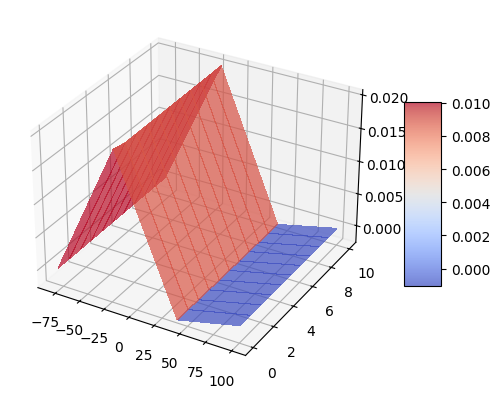

In [96]:
# plot 3d surface
# create a meshgrid of (x,t) points
# T and X are 2-d arrays
M, X = np.meshgrid(t,x)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# Use X and T arrays to plot u
# shape of X, T and u must to be the same
# but shape of u is [40,1601] and I will skip last row while plotting
surf = ax.plot_surface(X, M, T[:,:3800], rstride=1, cstride=1, cmap=cm.coolwarm, linewidth=0, antialiased=False, alpha=0.7)
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

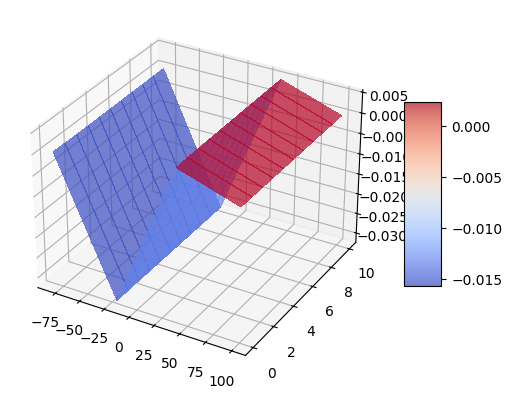

In [97]:
# plot 3d surface
# create a meshgrid of (x,t) points
# T and X are 2-d arrays
M, X = np.meshgrid(t,x)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# Use X and T arrays to plot u
# shape of X, T and u must to be the same
# but shape of u is [40,1601] and I will skip last row while plotting
surf = ax.plot_surface(X, M, T[:,:3800].imag, rstride=1, cstride=1, cmap=cm.coolwarm, linewidth=0, antialiased=False, alpha=0.7)
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

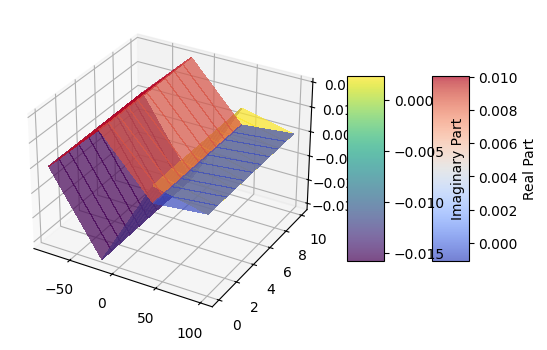

In [98]:
M, X = np.meshgrid(t, x)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the real part of T
surf_real = ax.plot_surface(X, M, T[:,:3800].real, rstride=1, cstride=1, cmap=cm.coolwarm, linewidth=0, antialiased=False, alpha=0.7)

# Plot the imaginary part of T
surf_imag = ax.plot_surface(X, M, T[:,:3800].imag, rstride=1, cstride=1, cmap=cm.viridis, linewidth=0, antialiased=False, alpha=0.7)

fig.colorbar(surf_real, shrink=0.5, aspect=5, label='Real Part')
fig.colorbar(surf_imag, shrink=0.5, aspect=5, label='Imaginary Part')

plt.show()